# Python Crash Course  
---

MSc in Applied Mathematics (Imperial College London)  

**Duration:** 3 hours  
**Note:** Check [here](https://github.com/lucasmoschen/PyCrashCourse-AppliedMath-MSc) for additional material for the course.

Welcome! In this crash course, we'll see the foundation of *Python* for scientific computing so that everyone can feel comfortable with core Python and the essential scientific computing used across applied mathematics.

We'll explore Python's core features and the two libraries you'll use most often in this MSc: **NumPy** (for arrays and linear algebra) and **Matplotlib** (for plotting and visualization).

**Learning outcomes**

By the end of the session, you should be able to:

- Run Python code in Jupyter/Colab and write basic scripts;
- Work with Python data types, control flow, and functions;
- Use NumPy arrays for vectorized computations (faster);
- Solve linear systems and compute basic statistics;
- Create simple plots (lines, scatter, histograms).

**Recommended environment**

- JupyterLab or Jupyter Notebook 
- Alternatively: Google Colab (no local install required)
- **Remark:** to run more complex codes, "*.py" files are a better option

**Reference links**

- Python tutorial: <https://docs.python.org/3/tutorial/>
- Official NumPy user guide: <https://numpy.org/doc/stable/user/>
- Matplotlib tutorials: <https://matplotlib.org/stable/tutorials/>
- PEP 8 (style guide): <https://peps.python.org/pep-0008/> 
- Real Python: <https://realpython.com/>

## 0. Getting Started

Run a couple of lines to verify your environment.

In [1]:
print("Hello, MSc Applied Mathematics cohort!")

Hello, MSc Applied Mathematics cohort!


In [2]:
2 + 3 * 5 

17

In [3]:
10 // 3, 10 / 3, 10 % 3

(3, 3.3333333333333335, 1)


## 1. Python Basics

### Variables & Types

Python is dynamically typed. The most common built-in types you'll use early:

- `int`, `float`, `str`, `bool`
- `list`, `tuple`, `dict`, `set`

Below, experiment with assignments and observe types.

In [4]:
x = 3
y = 2.5
name = "Alice"
is_math_student = True

print(type(x), type(y), type(name), type(is_math_student))

<class 'int'> <class 'float'> <class 'str'> <class 'bool'>


In [5]:
print(type(2.0))

<class 'float'>


In [6]:
x + y 

5.5

We cannot sum objects with different types.

In [7]:
x + name

TypeError: unsupported operand type(s) for +: 'int' and 'str'

In [8]:
name + name

'AliceAlice'


### Lists, Tuples, Dictionaries
- **Lists** are ordered, mutable sequences.
- **Tuples** are ordered, immutable sequences.
- **Dictionaries** map keys to values.


In [9]:
numbers = [1, 2, 3, 4, 5] # this is a list of elements
point = (3, 4) # this is a tuple, can't change after defining it
grades = {"Alice": 90, "Bob": 85}
numbers, point, grades

([1, 2, 3, 4, 5], (3, 4), {'Alice': 90, 'Bob': 85})

Assignment with an "=" on lists does not make a copy. 
Iakes the two variables **point** to the one list in memory.

In [10]:
x = [1, 2, 3, 4] # creates a list and assigns to the variable x
y = x # creates y and assigns to it x
y[0] = 3 # modify the list y, which is actually x
print(x)

[3, 2, 3, 4]


Tuples do not have this behaviour.

In [11]:
x = (1, 2, 3, 4) # creates a tuple and assigns to the variable x
y = x # creates y and assigns to it x
y[0] = 3 # modify the list y, which is actually x
print(x)

TypeError: 'tuple' object does not support item assignment

### Indexing & Slicing

Python uses **0-based indexing**. Negative indices count from the end.

In [12]:
print(numbers[0], numbers[-1])
print(numbers[1:4])  # slice from index 1 (inclusive) to 4 (exclusive)

1 5
[2, 3, 4]


In [13]:
numbers[-2:-1]

[4]

I can also take the numbers from 0 to 4 (exclusive) two by two. 

In [14]:
numbers[0:4:2]

[1, 3]

### Modifying

Let us change the list by (1) appending a value; (2) inserting a number in the index 3; (3) sorting it; and (4) removing the value at index 2. 

In [15]:
numbers.append(2.5)
print(numbers)

[1, 2, 3, 4, 5, 2.5]


In [16]:
numbers.insert(3, 1.5)
print(numbers)

[1, 2, 3, 1.5, 4, 5, 2.5]


In [17]:
numbers.sort()
numbers

[1, 1.5, 2, 2.5, 3, 4, 5]

In [18]:
print(numbers.pop(3))
print(numbers)

2.5
[1, 1.5, 2, 3, 4, 5]


In [19]:
numbers + numbers

[1, 1.5, 2, 3, 4, 5, 1, 1.5, 2, 3, 4, 5]

We cannot modify a tuple.

In [20]:
point.count(3)

1

In [21]:
point.index(3)

0

Dictionaries can also be modified.

In [22]:
grades.update({'Alice': 100})
print(grades)

{'Alice': 100, 'Bob': 85}


In [23]:
grades['Cezar'] = 30
print(grades)

{'Alice': 100, 'Bob': 85, 'Cezar': 30}


In [24]:
grades.get('Bob')

85

In [25]:
grades.items()

dict_items([('Alice', 100), ('Bob', 85), ('Cezar', 30)])

**Dictionaries and lists are stored differently in memory.**
To see why that matters, let’s build a long list and a long dictionary (using some shortcuts) and then compare how much time it takes to search for an element in each.

* `range(n)` defines a sequence from `0` to `n-1`. We can convert it into a list with `list(range(n))`.
* `[i for i in range(100)]` and `{i: something for i in range(100)}` are called **comprehensions**. They are compact ways of building lists and dictionaries.
* I won’t cover comprehensions in detail right now, but there will be **extra exercises** for those interested.

In [26]:
target = 99_999_999

In [27]:
%time numbers = list(range(100_000_000))

CPU times: user 508 ms, sys: 180 ms, total: 688 ms
Wall time: 690 ms


In [28]:
%time numbers_dict = zip(range(100_000_000), [True]*100_000_000)

CPU times: user 22.4 ms, sys: 41.8 ms, total: 64.2 ms
Wall time: 102 ms


In [29]:
%time numbers_dict = {i: True for i in range(100_000_000)}

CPU times: user 2.8 s, sys: 1.49 s, total: 4.29 s
Wall time: 5.18 s


In [30]:
%time found = target in numbers

CPU times: user 551 ms, sys: 565 ms, total: 1.12 s
Wall time: 1.29 s


In [31]:
%time found_dict = target in numbers_dict

CPU times: user 2 µs, sys: 6 µs, total: 8 µs
Wall time: 7.87 µs


### Control Flow: `if`, `for`, `while`

Use `range(n)` to generate integer sequences. Try modifying the code.

In [32]:
for i in range(5):
    print(f"{i}^2 = {i**2}")

0^2 = 0
1^2 = 1
2^2 = 4
3^2 = 9
4^2 = 16


Check if an element is in a list

In [33]:
treats = ["muffins", "cookies", "chocolate"]

favourite = "pancakes"

print("Is favourite in the treats list? ", favourite in treats)

Is favourite in the treats list?  False


In [34]:
numbers = ["2", "3", "4"]

favourite_number = 2

print("Is favourite in the numbers list? ", favourite in treats)

Is favourite in the numbers list?  False


The logic with mathematical terms

$$
f(n) = 
\begin{cases}
\text{a lot} & n \ge 200 \\
\text{very few} & n \le 5 \\
\text{fair} & 5 < n \le 50 \\
n & \text{otherwise}
\end{cases}
$$

We also have the `while`. Suppose we need to perform a specific experiment $110$ times. We have already performed $100$ of them. 

In [36]:
ready_simulations = 100



We have 100 ready_simulations ready. It is True that we need more.


In [37]:
def perform_simulation(ready_simulations):
    # do your simulation as you want.
    return ready_simulations + 1

while ready_simulations < 110:
    ready_simulations = perform_simulation(ready_simulations)
    print(f"Simulation {ready_simulations} done!")

Simulation 101 done!
Simulation 102 done!
Simulation 103 done!
Simulation 104 done!
Simulation 105 done!
Simulation 106 done!
Simulation 107 done!
Simulation 108 done!
Simulation 109 done!
Simulation 110 done!


### Functions & Modules

Functions encapsulate logic. Modules package reusable code.

In [38]:
import math

def area_circle(r: float) -> float:
    return math.pi * r**2

print(area_circle(1.5))

7.0685834705770345


In [39]:
help(math.cos)

Help on built-in function cos in module math:

cos(x, /)
    Return the cosine of x (measured in radians).




### 📝 Exercise 1 (basic functions)
1. Implement a function `factorial(n)` using a loop.
2. Test for `n=5` and compare with `math.factorial`.


Notice the `n: int -> int`. These are **type hints**. Python doesn’t enforce them at runtime - they’re for humans and tools. You can leave them out, but including them makes your code clearer.

Check your code with `factorial(2.5)`

In [1]:
#factorial(2.5)

### 📝 Exercise 2 (simulation & randomness)

Simulate rolling two dice until a **double** appears (e.g., 1-1, 6-6). 
The function should return the number of necessary rolls for that to happen (rolls >= 1). 
Then, repeat the experiment 1000 times and compute the average number of rolls.
Print this value.

*Hint:* use `random.randint(1,6)`.

## 2. NumPy for Numerics

**NumPy** provides fast multidimensional arrays and vectorized operations, crucial for scientific computing.

Key points:

- Arrays are **homogeneous** (all elements of the same type) and efficient.
- Avoid Python loops when possible; prefer **vectorized** NumPy operations. 
- Broadcasting rules let arrays of different shapes interact when compatible.

In [43]:
# this will bring numpy to the environment and call it "np".
# I can name numpy any other name, but "np" is the standard one.
import numpy as np

In [44]:
a = np.array([1, 2, 3]) # creates an array from a list. 
b = np.array([4, 5, 6])
print("a + b =", a + b)
print("a * b =", a * b)              # element-wise product
print("a / b =", a / b)              # element-wise division
print("dot(a, b) =", np.dot(a, b))  # inner product

a + b = [5 7 9]
a * b = [ 4 10 18]
a / b = [0.25 0.4  0.5 ]
dot(a, b) = 32


Notice that summing lists gives a different result!

In [45]:
[1, 2, 3] + [4, 5, 6]

[1, 2, 3, 4, 5, 6]

### Creating arrays 

There are different ways to define a larger array easily.
The most commons are below

In [46]:
print("np.arange:", np.arange(5))
print("np.arange:", np.arange(start=2, stop=10, step=3))
print("np.arange:", np.arange(start=2, stop=10, step=0.5))

np.arange: [0 1 2 3 4]
np.arange: [2 5 8]
np.arange: [2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5 9.  9.5]


In [47]:
print("np.linspace:", np.linspace(start=0, stop=1, num=10))

np.linspace: [0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ]


In [48]:
print("np.zeros((2,3)):\n", np.zeros(shape=(2,3)))
print("np.ones((2,3)):\n", np.ones(shape=(2,3)))

np.zeros((2,3)):
 [[0. 0. 0.]
 [0. 0. 0.]]
np.ones((2,3)):
 [[1. 1. 1.]
 [1. 1. 1.]]


### Shapes, Slicing, Broadcasting

In [49]:
A = np.arange(12).reshape(3,4)
print(A)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [50]:
A.reshape(2,1,3,2)

array([[[[ 0,  1],
         [ 2,  3],
         [ 4,  5]]],


       [[[ 6,  7],
         [ 8,  9],
         [10, 11]]]])

In [51]:
A[0,1] # element at row 0 and column 1

np.int64(1)

In [52]:
A[1, :] # row 1 (second row)

array([4, 5, 6, 7])

In [53]:
A[:, 2] # column 2 (third column)

array([ 2,  6, 10])

#### 📝 Practice

1. Create a 1D array with the numbers from 0 to 19.
2. Extract:
   * The first 5 elements.
   * The last 5 elements.
   * Every second element.
3. Create a 2D array with numbers 1 to 12 arranged as 3 rows × 4 columns.
4. From this 2D array, extract:
   * The second row.
   * The last column.
   * The subarray

     ```
     [[6, 7],
      [10, 11]]
     ```

### Broadcasting

NumPy automatically stretches arrays of compatible shapes. This avoids writing loops.

In [54]:
A + np.arange(4)

array([[ 0,  2,  4,  6],
       [ 4,  6,  8, 10],
       [ 8, 10, 12, 14]])

The number of columns should be the same.

In [55]:
A.reshape(4,3) + np.arange(4)

ValueError: operands could not be broadcast together with shapes (4,3) (4,) 

### Random numbers

In [56]:
A = np.random.rand(3,3)
b = np.random.rand(3)
A, b

(array([[0.73266655, 0.25302373, 0.74045353],
        [0.42505616, 0.22299564, 0.4861958 ],
        [0.12301801, 0.16702192, 0.22120203]]),
 array([0.53289023, 0.74395689, 0.41897169]))

In [57]:
np.random.normal()

-1.8237948647813513

In [58]:
np.random.chisquare(df=5, size=10)

array([6.14054909, 3.75380225, 2.34518969, 1.11270368, 7.72312566,
       2.30820835, 1.59564849, 7.25438955, 2.27216654, 5.8408379 ])

### Linear Algebra Basics

In [59]:
x = np.linalg.solve(A,b)
print("Solution x =", x)
print("Residual =", np.linalg.norm(A@x - b))

Solution x = [ 64.95420681  70.93797843 -87.7919736 ]
Residual = 6.71386663275302e-15


In [60]:
eigvals, eigenvectors = np.linalg.eig(A)
print("Eigenvalues:", eigvals)

Eigenvalues: [1.08997234 0.08425279 0.00263908]


In [61]:
np.linalg.norm(eigenvectors, axis=0)

array([1., 1., 1.])

In [62]:
np.linalg.norm(eigenvectors[:,0]), np.linalg.norm(eigenvectors[:,1]), np.linalg.norm(eigenvectors[:,2])

(np.float64(0.9999999999999999),
 np.float64(1.0),
 np.float64(0.9999999999999999))

In [63]:
print(np.abs(A[0,0]) + np.abs(A[0,1]) + np.abs(A[0,2]))
print(np.linalg.norm(A[0,:], ord=1))

1.7261438065478778
1.7261438065478778


### Statistics

In [64]:
samples = np.random.normal(size=1000)  # 1000 samples from N(0,1)
print("Mean:", samples.mean())
print("Variance:", samples.var())

Mean: 0.04569838655835674
Variance: 0.9907136559828194



### 📝 Exercise 3 (vectorization & stats)

- Generate $100,000$ samples from the binomial distribution with $n=10$ and $p=0.2$ and compute mean/variance.
- Compare to theoretical values. What happens as N grows?

2.00597 1.6103343590999997
2.0 1.6


### Python loops vs NumPy

NumPy is faster because it runs compiled code under the hood.

In [66]:
import time

N = 1_000_000
x = np.random.rand(N)
y = np.random.rand(N)

t0 = time.time()
dot1 = sum(xi*yi for xi,yi in zip(x,y))
t1 = time.time()

t2 = time.time()
dot2 = np.dot(x,y)
t3 = time.time()

print("Python loop:", t1-t0, "seconds")
print("NumPy dot:", t3-t2, "seconds")

Python loop: 0.08613395690917969 seconds
NumPy dot: 0.0020880699157714844 seconds


## 3. Plotting with Matplotlib

**Matplotlib** is the foundation for plotting in Python.  
Use `plt.plot` for line plots, `plt.scatter` for scatter, and `plt.hist` for histograms.

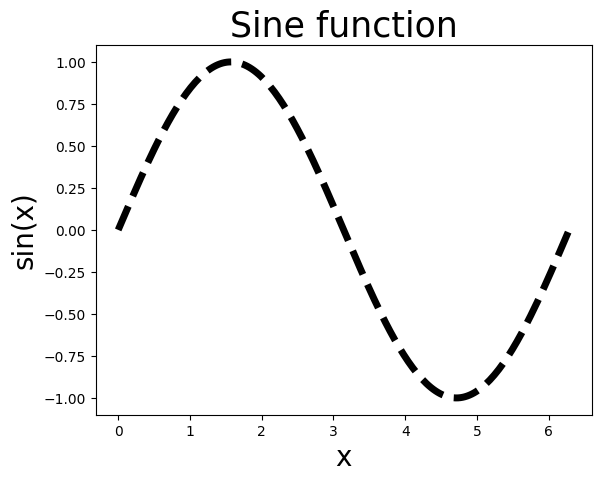

In [67]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 2*np.pi, 200)
y = np.sin(x)
plt.plot(x, y, color='black', linewidth=5, linestyle='--')
plt.title("Sine function", fontsize=25)
plt.xlabel("x", fontsize=20)
plt.ylabel("sin(x)", fontsize=20)
plt.show()

### 📝 Exercise 4 (histogram)

- Draw 10,000 samples from `N(mu,1)` for a given mu and plot a histogram.
- Draw a vertical line for the sample mean.

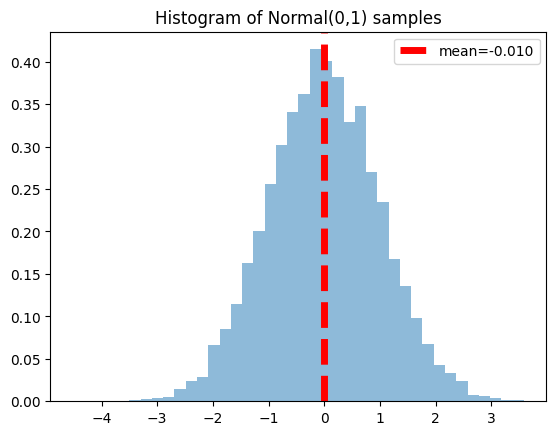

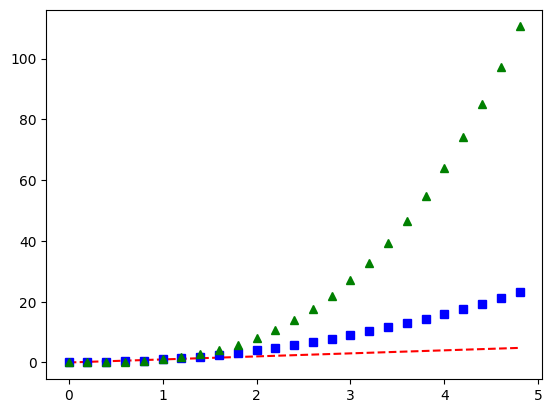

In [70]:
# evenly sampled time at 200ms intervals
t = np.arange(0., 5., 0.2)

# red dashes, blue squares, and green triangles
plt.plot(t, t, 'r--')
plt.plot(t, t**2, 'bs')
plt.plot(t, t**3, 'g^')
#plt.plot(t, t, 'r--', t, t**2, 'bs', t, t**3, 'g^')

plt.show()


---

## Cheatsheet & Next Steps

- **Slicing:** `a[start:stop:step]` with defaults for each piece
- **Vectorization:** avoid Python loops; use NumPy operations (`+`, `*`, `@`, `np.sum`, `np.mean`)
- **Broadcasting:** align trailing dimensions; size 1 dims stretch
- **Plotting:** `plt.plot`, `plt.scatter`, `plt.hist`; always label axes

**Practice**:
- Write and time a pure-Python loop vs. a NumPy vectorized operation.
- Solve several random linear systems; plot residuals’ histogram.
- Explore `np.linalg.svd`, and `np.random.default_rng`.

**Further reading**:
- NumPy broadcasting: <https://numpy.org/doc/stable/user/basics.broadcasting.html>
- Matplotlib gallery: <https://matplotlib.org/stable/gallery/>
- **Pandas** and **Scipy** are two other libraries that are essential.  
